In [1]:
from cpom.slopes.slopes import Slopes
from cpom.areas.areas import Area
import polars as pl


In [7]:
pl.read_parquet("/home/willisc3/luna/CPOM/willisc3/SEC/greenland_cs2_5km/interpolated_epoch_average_30/PETERMANN_GLETSCHER/interpolated.parquet")

y_bin,x_bin,epoch_number,dh_ave,dh_stddev,dh_ave_flag,dh_stddev_flag,epoch_midpoint_fractional_yr,epoch_midpoint_dt,epoch_lo_dt,epoch_hi_dt
i64,i64,i64,f64,f64,i8,i8,f64,datetime[μs],datetime[μs],datetime[μs]
403,202,0,0.028862,0.057634,1,1,19.835616,2010-11-02 00:00:00,2010-10-18 00:00:00,2010-11-17 00:00:00
404,202,0,0.01882,0.090604,1,1,19.835616,2010-11-02 00:00:00,2010-10-18 00:00:00,2010-11-17 00:00:00
405,201,0,0.045106,0.100311,2,2,19.835616,2010-11-02 00:00:00,2010-10-18 00:00:00,2010-11-17 00:00:00
406,200,0,0.041372,0.099202,2,2,19.835616,2010-11-02 00:00:00,2010-10-18 00:00:00,2010-11-17 00:00:00
406,201,0,0.098377,0.081746,2,2,19.835616,2010-11-02 00:00:00,2010-10-18 00:00:00,2010-11-17 00:00:00
…,…,…,…,…,…,…,…,…,…,…
504,158,174,-0.059575,0.634175,1,1,34.126027,2025-02-16 00:00:00,2025-02-01 00:00:00,2025-03-03 00:00:00
504,159,174,-0.030416,0.432032,2,2,34.126027,2025-02-16 00:00:00,2025-02-01 00:00:00,2025-03-03 00:00:00
504,160,174,0.023293,0.490811,2,2,34.126027,2025-02-16 00:00:00,2025-02-01 00:00:00,2025-03-03 00:00:00


In [3]:
slope_test = Slopes("arcticdem_cropped_100m_slope_svd_9x9_tif")

In [4]:
this_area = Area("greenland_is")

In [5]:
test_data = pl.read_parquet("/home/willisc3/luna/CPOM/willisc3/SEC/greenland_cs2_5km/gridded_altimetry/year=2012/**/*.parquet")

In [6]:
slope = slope_test.interp_slopes(test_data['x'], test_data['y'])
latitude, longitude = this_area.xy_to_latlon(test_data['x'], test_data['y'])
test_data = test_data.with_columns(pl.Series("slope", slope), pl.Series("latitude", latitude), pl.Series("longitude", longitude))

-------------------------------------------------------------
Background: basic_land
alpha= 1.0
Loading basic_land background
-------------------------------------------------------------
71.5 -41.75
(-655426.9213693695, 884573.0786306305)
(-3387695.941429183, -647695.9414291831)
display_polygon_mask False
loading data set 0: unnamed
-------------------------------------------------------------
Background: basic_land
alpha= 1.0
Loading basic_land background
-------------------------------------------------------------


/home/willisc3/cpom_software2/src/cpom/areas/area_plot.py:1561: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels(tick_labels)


drawing coastline for main map..
Adding map scale bar
Scalebar location latlon == x,y -35 60 577060.7250919531 -3272673.999029407
Scalebar width 400


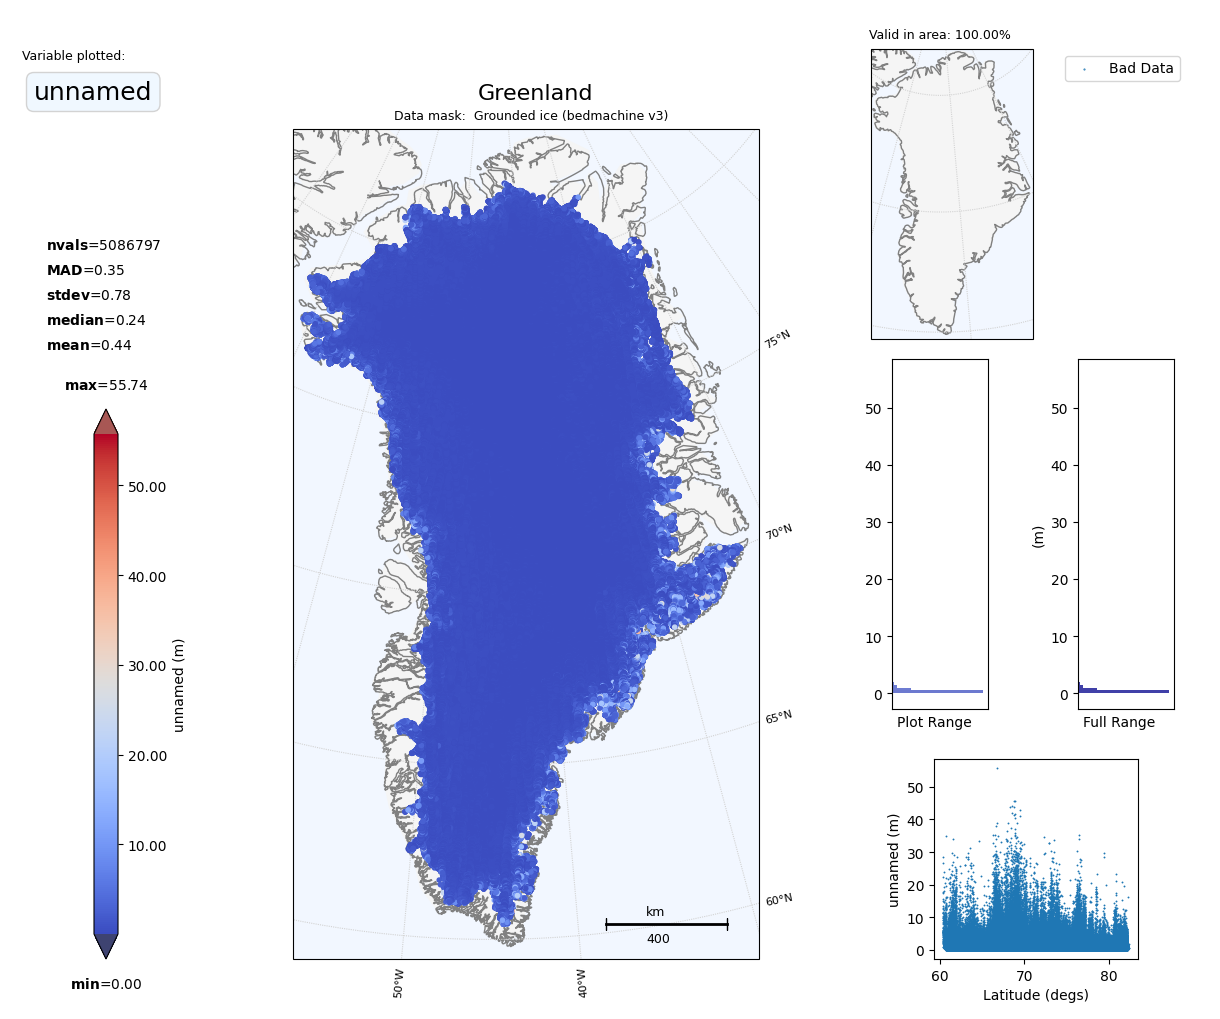

In [7]:
from cpom.areas.area_plot import Polarplot

Polarplot("greenland_is").plot_points(
    {
        "lats": test_data["latitude"],
        "lons": test_data["longitude"] % 360,
        "vals": test_data['slope'],
        # "valid_range": tuple(params.plot_range),
        "units": "m",
        "cmap_name": "coolwarm",
    },
)